In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
df = pd.read_csv("../datos_transformados/df_loads_trips.csv", sep = ',')

## <span style="color:orange">Análisis exhaustivo archivo loads_trips

Vamos a analizar columna por columna el archivo df_loads_trips

1. customer_id
2. route_id
3. load_date
4. load_type
5. weight_lbs
6. pieces
7. revenue
8. fuel_surcharge
9. accessorial_charges
10. booking_type
11. driver_id
12. truck_id
13. trailer_id
14. dispatch_date
15. actual_distance_miles
16. actual_duration_hours
17. fuel_gallons_used
18. average_mpg
19. idle_time_hours
20. total_revenue

<span style="color:orange">1. **customer_id**

Columna del ID correspondiente al cliente, registra el número de viajes realizados para cada cliente.
<br> Formato: CUST0000
<br> Mayor valor: CUST00181 -> 497 Viajes
<br> Menos valor: CUST00089 -> 374 Viajes


In [2]:
df['customer_id'].value_counts()

customer_id
CUST00181    497
CUST00133    489
CUST00111    487
CUST00077    487
CUST00196    483
            ... 
CUST00069    381
CUST00041    377
CUST00109    375
CUST00151    374
CUST00089    374
Name: count, Length: 200, dtype: int64

<span style="color:orange">2. **route_id**

Columna del ID correspondiente a la ruta, tenemos 58 Ids distintos.
<br> Formato: RTE00000
<br> Mayor nº apariciones: RTE00047 -> Aparece 1628 veces
<br> Menor nº apariciones: RTE00053 -> Aparece 1386 veces

In [3]:
df['route_id'].nunique()
df['route_id'].value_counts()

route_id
RTE00047    1628
RTE00015    1537
RTE00046    1534
RTE00048    1525
RTE00036    1522
RTE00028    1518
RTE00045    1514
RTE00012    1507
RTE00031    1505
RTE00007    1502
RTE00011    1501
RTE00043    1500
RTE00024    1497
RTE00003    1496
RTE00033    1491
RTE00027    1491
RTE00052    1490
RTE00014    1487
RTE00020    1485
RTE00002    1481
RTE00051    1480
RTE00005    1479
RTE00037    1477
RTE00009    1477
RTE00017    1473
RTE00021    1473
RTE00050    1472
RTE00034    1472
RTE00054    1472
RTE00032    1472
RTE00056    1471
RTE00057    1469
RTE00010    1468
RTE00029    1467
RTE00016    1465
RTE00013    1462
RTE00008    1461
RTE00049    1461
RTE00006    1460
RTE00004    1459
RTE00001    1456
RTE00018    1456
RTE00025    1450
RTE00042    1447
RTE00030    1445
RTE00040    1444
RTE00019    1443
RTE00055    1443
RTE00035    1441
RTE00039    1440
RTE00026    1440
RTE00058    1432
RTE00041    1429
RTE00038    1425
RTE00022    1424
RTE00044    1410
RTE00023    1398
RTE00053    1386
Name:

<span style="color:orange">3. **load_date**

Fechas en las que se realizaron las cargas
<br> Formato: YYYY-MM-DD
<br> Rango: Desde 2022-01-01 hasta 2024-12-31
<br> Mayor nº apariciones: 2022-05-18 -> Aparece 108 veces
<br> Menor nº apariciones: 2022-03-20 y 2023-10-03 -> Aparece 54 veces

In [4]:
df['load_date'].sort_values()
df['load_date'].value_counts()

load_date
2022-05-18    108
2022-06-12    106
2022-02-17    106
2022-08-29    102
2022-01-15    101
             ... 
2023-03-26     56
2023-10-09     56
2023-08-09     56
2023-10-03     54
2022-03-20     54
Name: count, Length: 1096, dtype: int64

<span style="color:orange">4. **load_type**

Tipo de carga
<br> Formato: Refrigerated / Dry Van
<br> Refrigerated aparece 42946
<br> Dry Van aparece 42464

In [5]:
df['load_type'].value_counts()
df.groupby('load_type')['weight_lbs'].count()

load_type
Dry Van         42464
Refrigerated    42946
Name: weight_lbs, dtype: int64

<span style="color:orange">5. **weight_lbs**

Peso de la carga en libras
<br> Formato: int
<br> Rango: Desde 10000 hasta 45000
<br> No vemos un rango de pesos dominante.
<br> En la matriz de correlación no vemos ninguna relación con el resto de variables, ya que podríamos pensar que a mayor peso de la carga, mayor gasto de combustible, pero no es así.


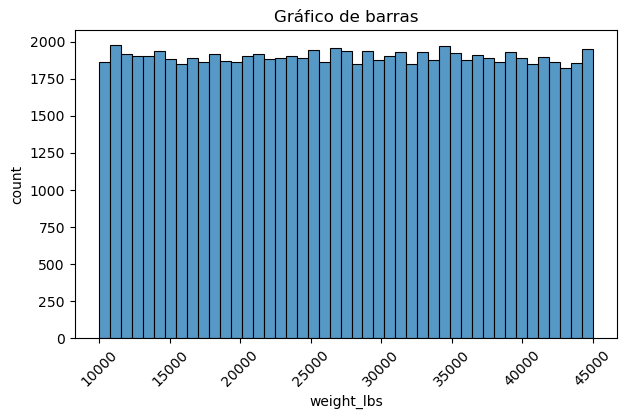

In [6]:
df['weight_lbs'].value_counts().sort_values()

# Visualizar count de pesos
width = 7
height = 4

plt.figure(figsize=(width, height))
sns.histplot(data=df, x=df['weight_lbs'])

plt.title(f'Gráfico de barras')
plt.xlabel('weight_lbs')
plt.ylabel('count')
plt.xticks(rotation=45)

plt.show()

<span style="color:orange">6. **pieces**

Cantidad de bultos en la carga
<br> Formato: int
<br> Rango: Desde 1 hasta 28
<br> No vemos un rango de nº de bultos dominante.
<br> En la matriz de correlación no vemos ninguna relación con el resto de variables.


In [7]:
df['pieces'].value_counts().sort_values(ascending=False).head(5)

pieces
13    3191
4     3115
20    3112
17    3096
3     3095
Name: count, dtype: int64

<span style="color:orange">7. **revenue**

Cantidad de befeficios brutos, es un KPI importante, pero no el principal
<br> Formato: float
<br> Rango: Desde 125.93 hasta 8125.22
<br> Fuerte correlación positiva con fuel_surcharge, actual_distance_miles, actual_duration_hours, fuel_gallons_used y total_revenue.


In [8]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'booking_type', 'driver_id', 'truck_id',
       'trailer_id', 'dispatch_date', 'actual_distance_miles',
       'actual_duration_hours', 'fuel_gallons_used', 'average_mpg',
       'idle_time_hours', 'total_revenue'],
      dtype='object')

In [9]:
df['revenue'].min()
df['revenue'].max()

8125.22

<span style="color:orange">8. **fuel_surcharge**

Cantidad de gasto del recargo por combustible consumido durante el viaje
<br> Formato: float
<br> Rango: Desde 13.8 hasta 891.82
<br> Fuerte correlación positiva con actual_distance_miles, actual_duration_hours, fuel_gallons_used, revenue y total_revenue.


In [10]:
df['fuel_surcharge'].min()
df['fuel_surcharge'].max()

891.82

<span style="color:orange">9. **accesorial_charges**

Cantidad de gasto por otro tipo de gastos ocurridos durante el viaje
<br> Formato: int
<br> Rango: Desde 0 hasta 200
<br> Podemos observar que tenemos un 62,26% de los viajes con recargos, los contratos tipo Contract son los que más gastos de este tipo generan en comparación con Spot o Dedicated

In [11]:
df['accessorial_charges'].dtype
df['accessorial_charges'].min()
df['accessorial_charges'].max()
(df[df['accessorial_charges'] > 0].value_counts().sum() * 100 / df.value_counts().sum()).round(2)

np.float64(62.26)

<Axes: xlabel='accessorial_charges', ylabel='booking_type'>

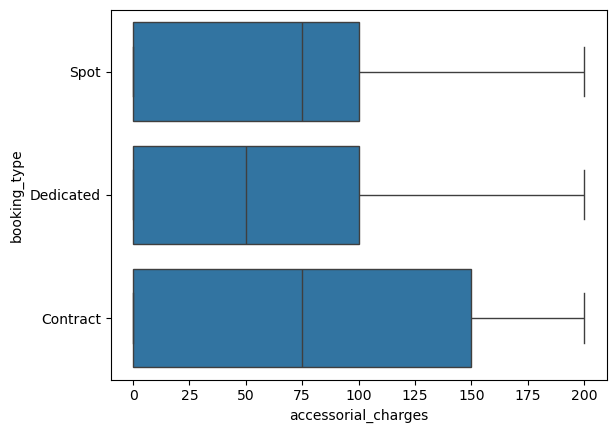

In [12]:
sns.boxplot(
    data=df,
    x='accessorial_charges',
    y='booking_type'
)

<span style="color:orange">10. **booking_type**

Tipo de viaje realizado, hay 3
<br> Formato: str
<br> Rango: Dedicated, Contract, Spot
<br> Vemos que aprox un 50% de los viajes es de tipo Dedicated, señalar que los tipo contract aunque sean un 25% de los registros, son los que más gastos por accesorios generan.

In [13]:
df['booking_type'].value_counts()

booking_type
Dedicated    42337
Contract     21545
Spot         21528
Name: count, dtype: int64

<Axes: xlabel='idle_time_hours', ylabel='booking_type'>

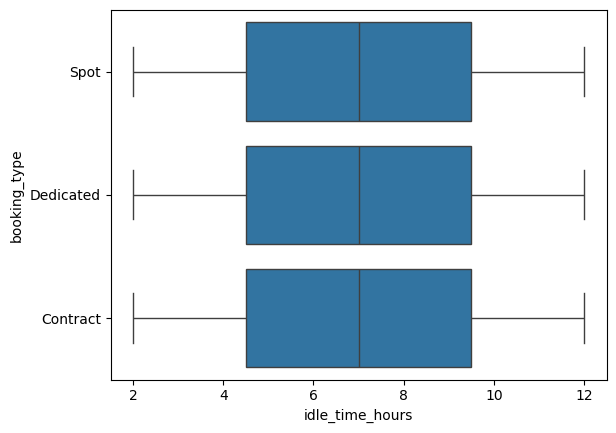

In [14]:
sns.boxplot(
    data=df,
    x='idle_time_hours',
    y='booking_type'
)

<span style="color:orange">11. **driver_id**

ID del conductor que realiza el viaje
<br> Formato: str (DRV00000)
<br> Tenemos un total de 124 conductores, en el heatmap podemos buscar cuáles son más comunes dependiendo de la ruta.
<br> Aunque no se ven diferencias muy marcadas, podemos sacar rankings de conductores, al igual que en camiones (más abajo), el id de los conductores se repite en muchos rankings

In [15]:
df['driver_id'].nunique()

124

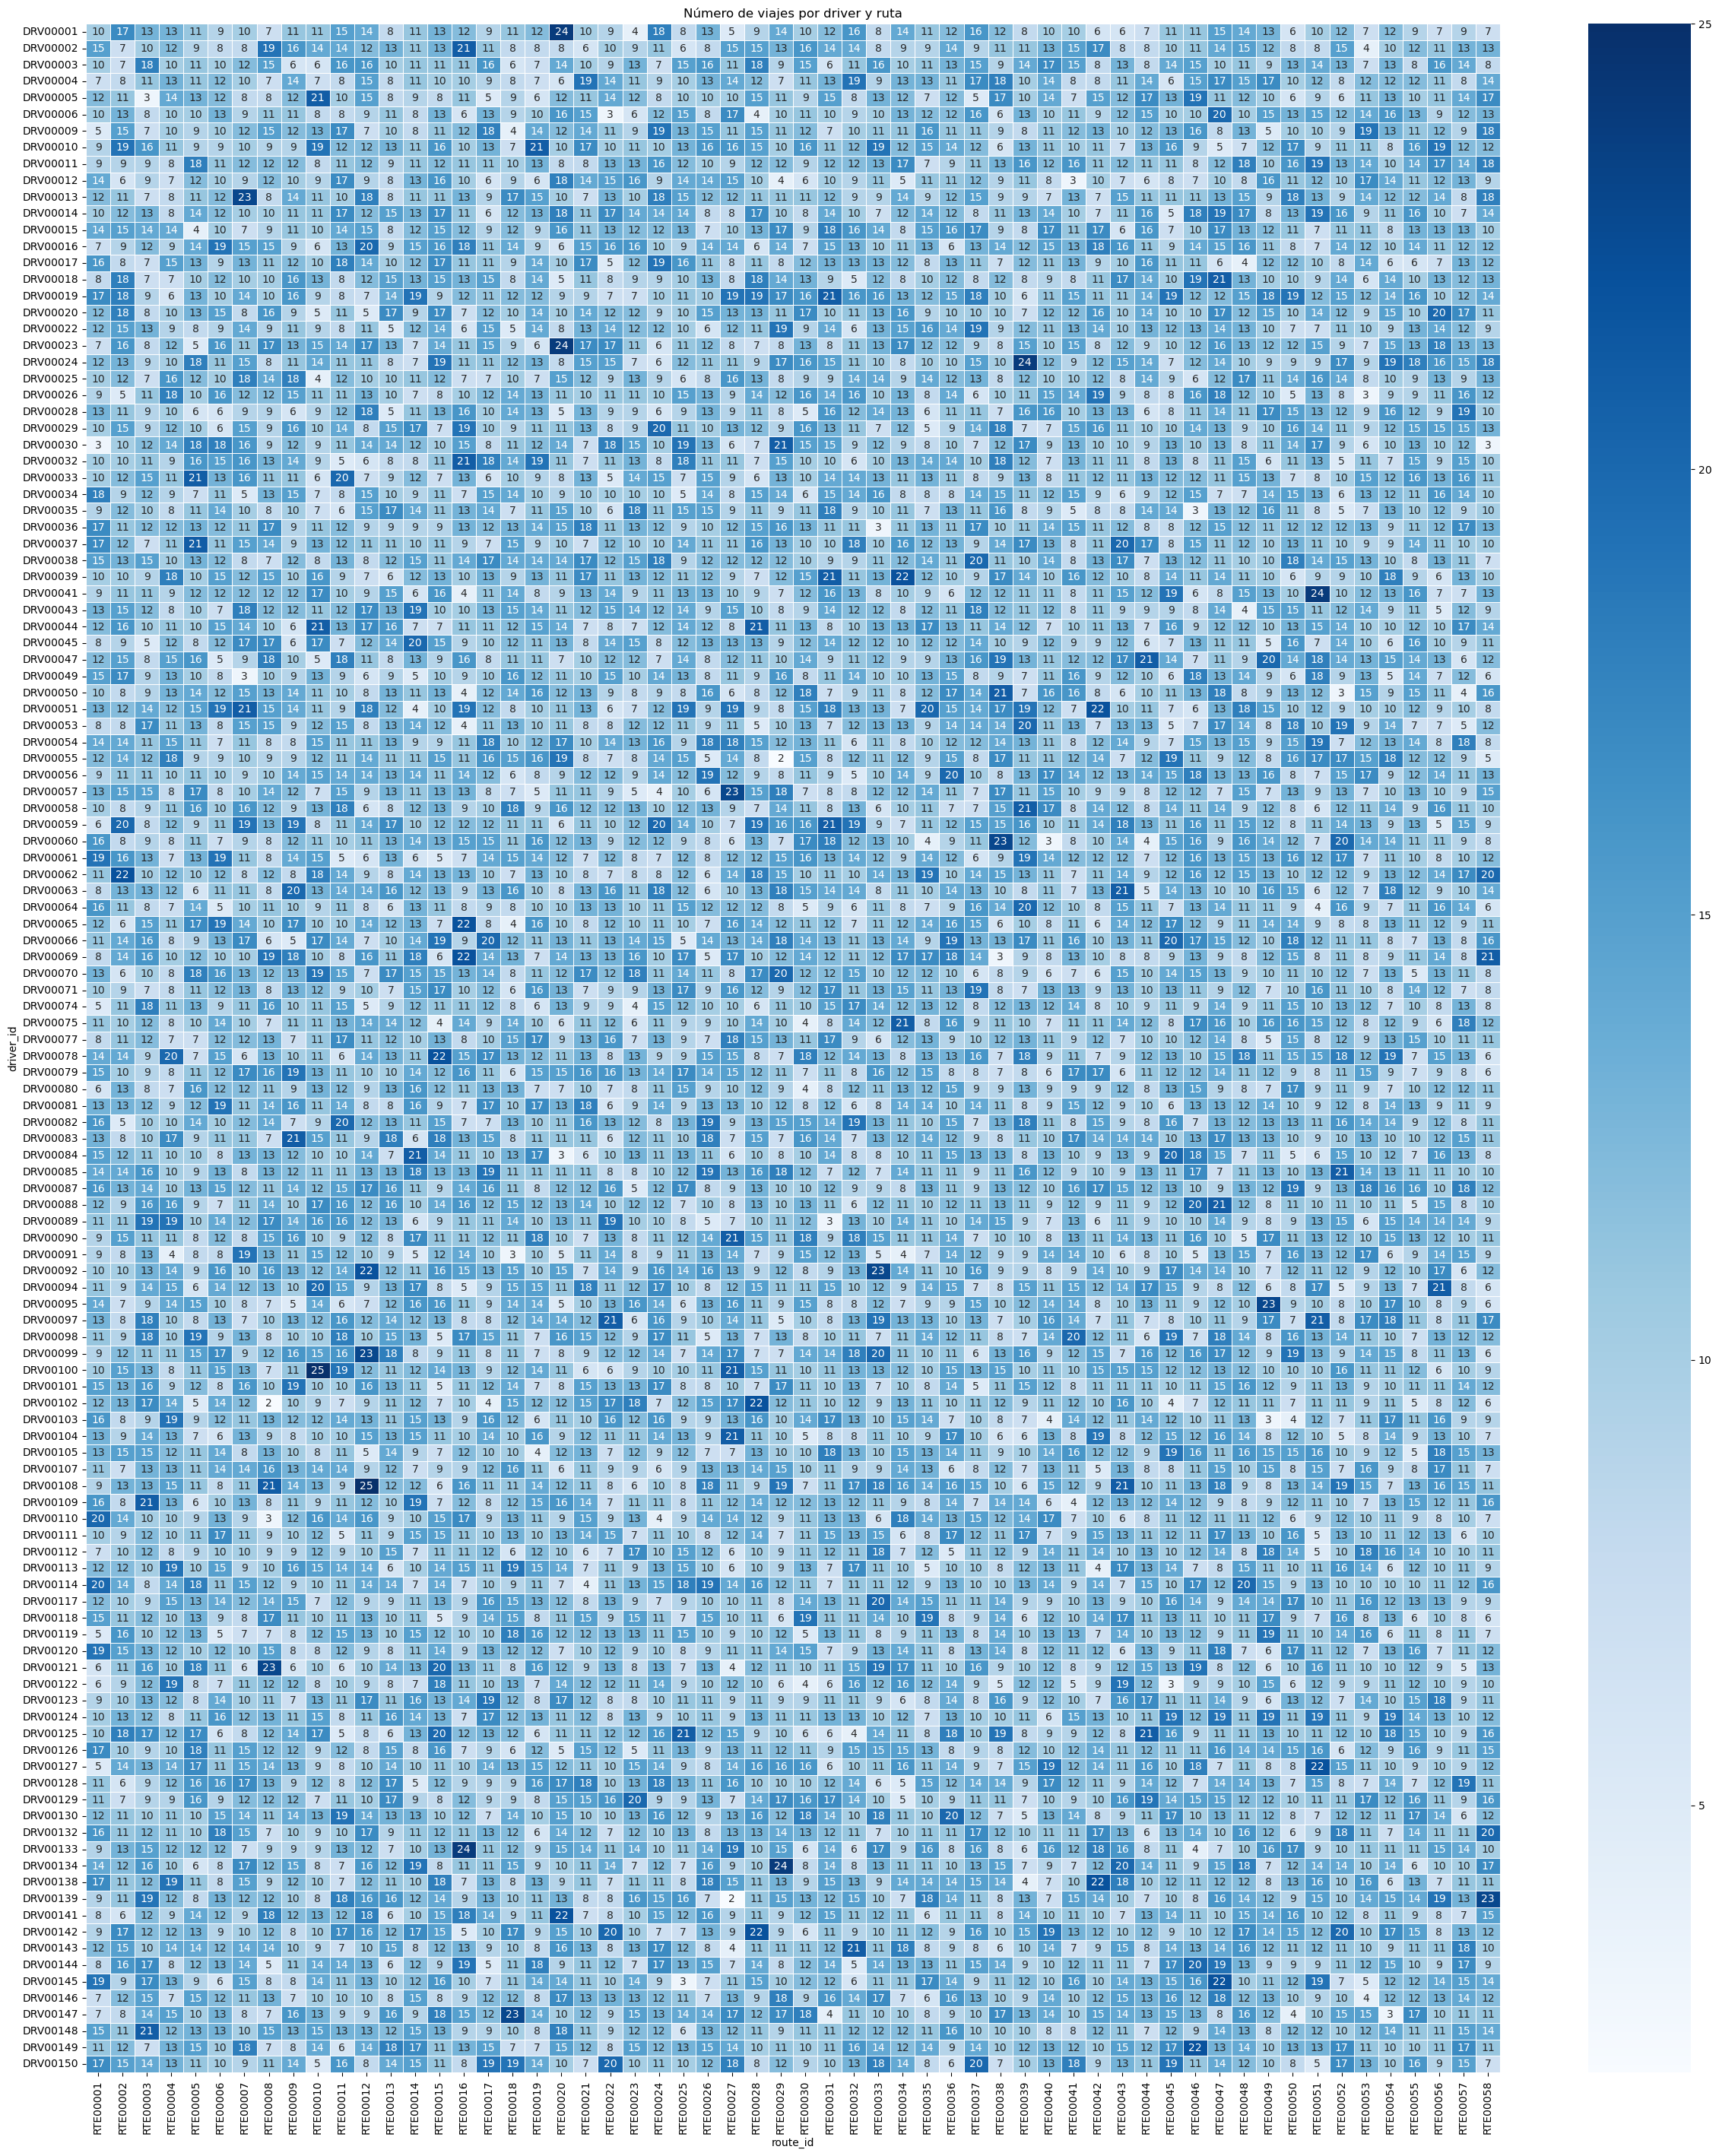

In [16]:
data = df.pivot_table(
    index="driver_id",
    columns="route_id",
    aggfunc="size",
    fill_value=0
)

f, ax = plt.subplots(figsize=(30, 35))
sns.heatmap(
    data,
    annot=True,
    fmt="d",
    linewidths=.5,
    cmap="Blues",
    ax=ax
)
plt.title("Número de viajes por driver y ruta")
plt.show()


In [17]:
top_10_conductores_viajes = (
    df
    .groupby("driver_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
top_10_conductores_viajes

driver_id
DRV00019    749
DRV00066    737
DRV00108    735
DRV00059    729
DRV00087    725
DRV00051    723
DRV00149    721
DRV00078    717
DRV00016    712
DRV00142    711
dtype: int64

In [18]:
columns = ['revenue', 'fuel_surcharge', 'accessorial_charges', 'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'total_revenue']

for col in columns:
    top_10 = (
    df.groupby("driver_id")[col].sum()
    .sort_values(ascending=False)
    .head(10)
    )
    print(f'\n---------------------- Top 10 {col} ----------------------')
    print(top_10)




---------------------- Top 10 revenue ----------------------
driver_id
DRV00051    2311844.30
DRV00108    2311327.90
DRV00059    2305056.60
DRV00016    2278574.88
DRV00019    2275654.76
DRV00127    2272317.62
DRV00149    2269105.67
DRV00147    2256066.92
DRV00085    2229521.23
DRV00087    2214003.33
Name: revenue, dtype: float64

---------------------- Top 10 fuel_surcharge ----------------------
driver_id
DRV00127    263838.59
DRV00019    262313.24
DRV00051    261225.68
DRV00108    260226.84
DRV00059    260137.81
DRV00149    258891.57
DRV00147    257548.06
DRV00085    257456.21
DRV00066    255402.35
DRV00016    251986.87
Name: fuel_surcharge, dtype: float64

---------------------- Top 10 accessorial_charges ----------------------
driver_id
DRV00099    55450
DRV00059    54625
DRV00108    54200
DRV00092    53850
DRV00085    53450
DRV00037    52925
DRV00142    52725
DRV00124    52700
DRV00066    52425
DRV00024    52300
Name: accessorial_charges, dtype: int64

---------------------- Top 

<span style="color:orange">12. **truck_id**

ID del camión que realiza el viaje
<br> Formato: str (TKR00000)
<br> Tenemos un total de 92 camiones, en el heatmap podemos buscar cuáles son más comunes dependiendo de la ruta.
<br> Aunque no se ven diferencias muy marcadas, podemos sacar rankings de camiones, se observa que hay varios Ids que se repiten en los rankings

In [19]:
df['truck_id'].nunique()

92

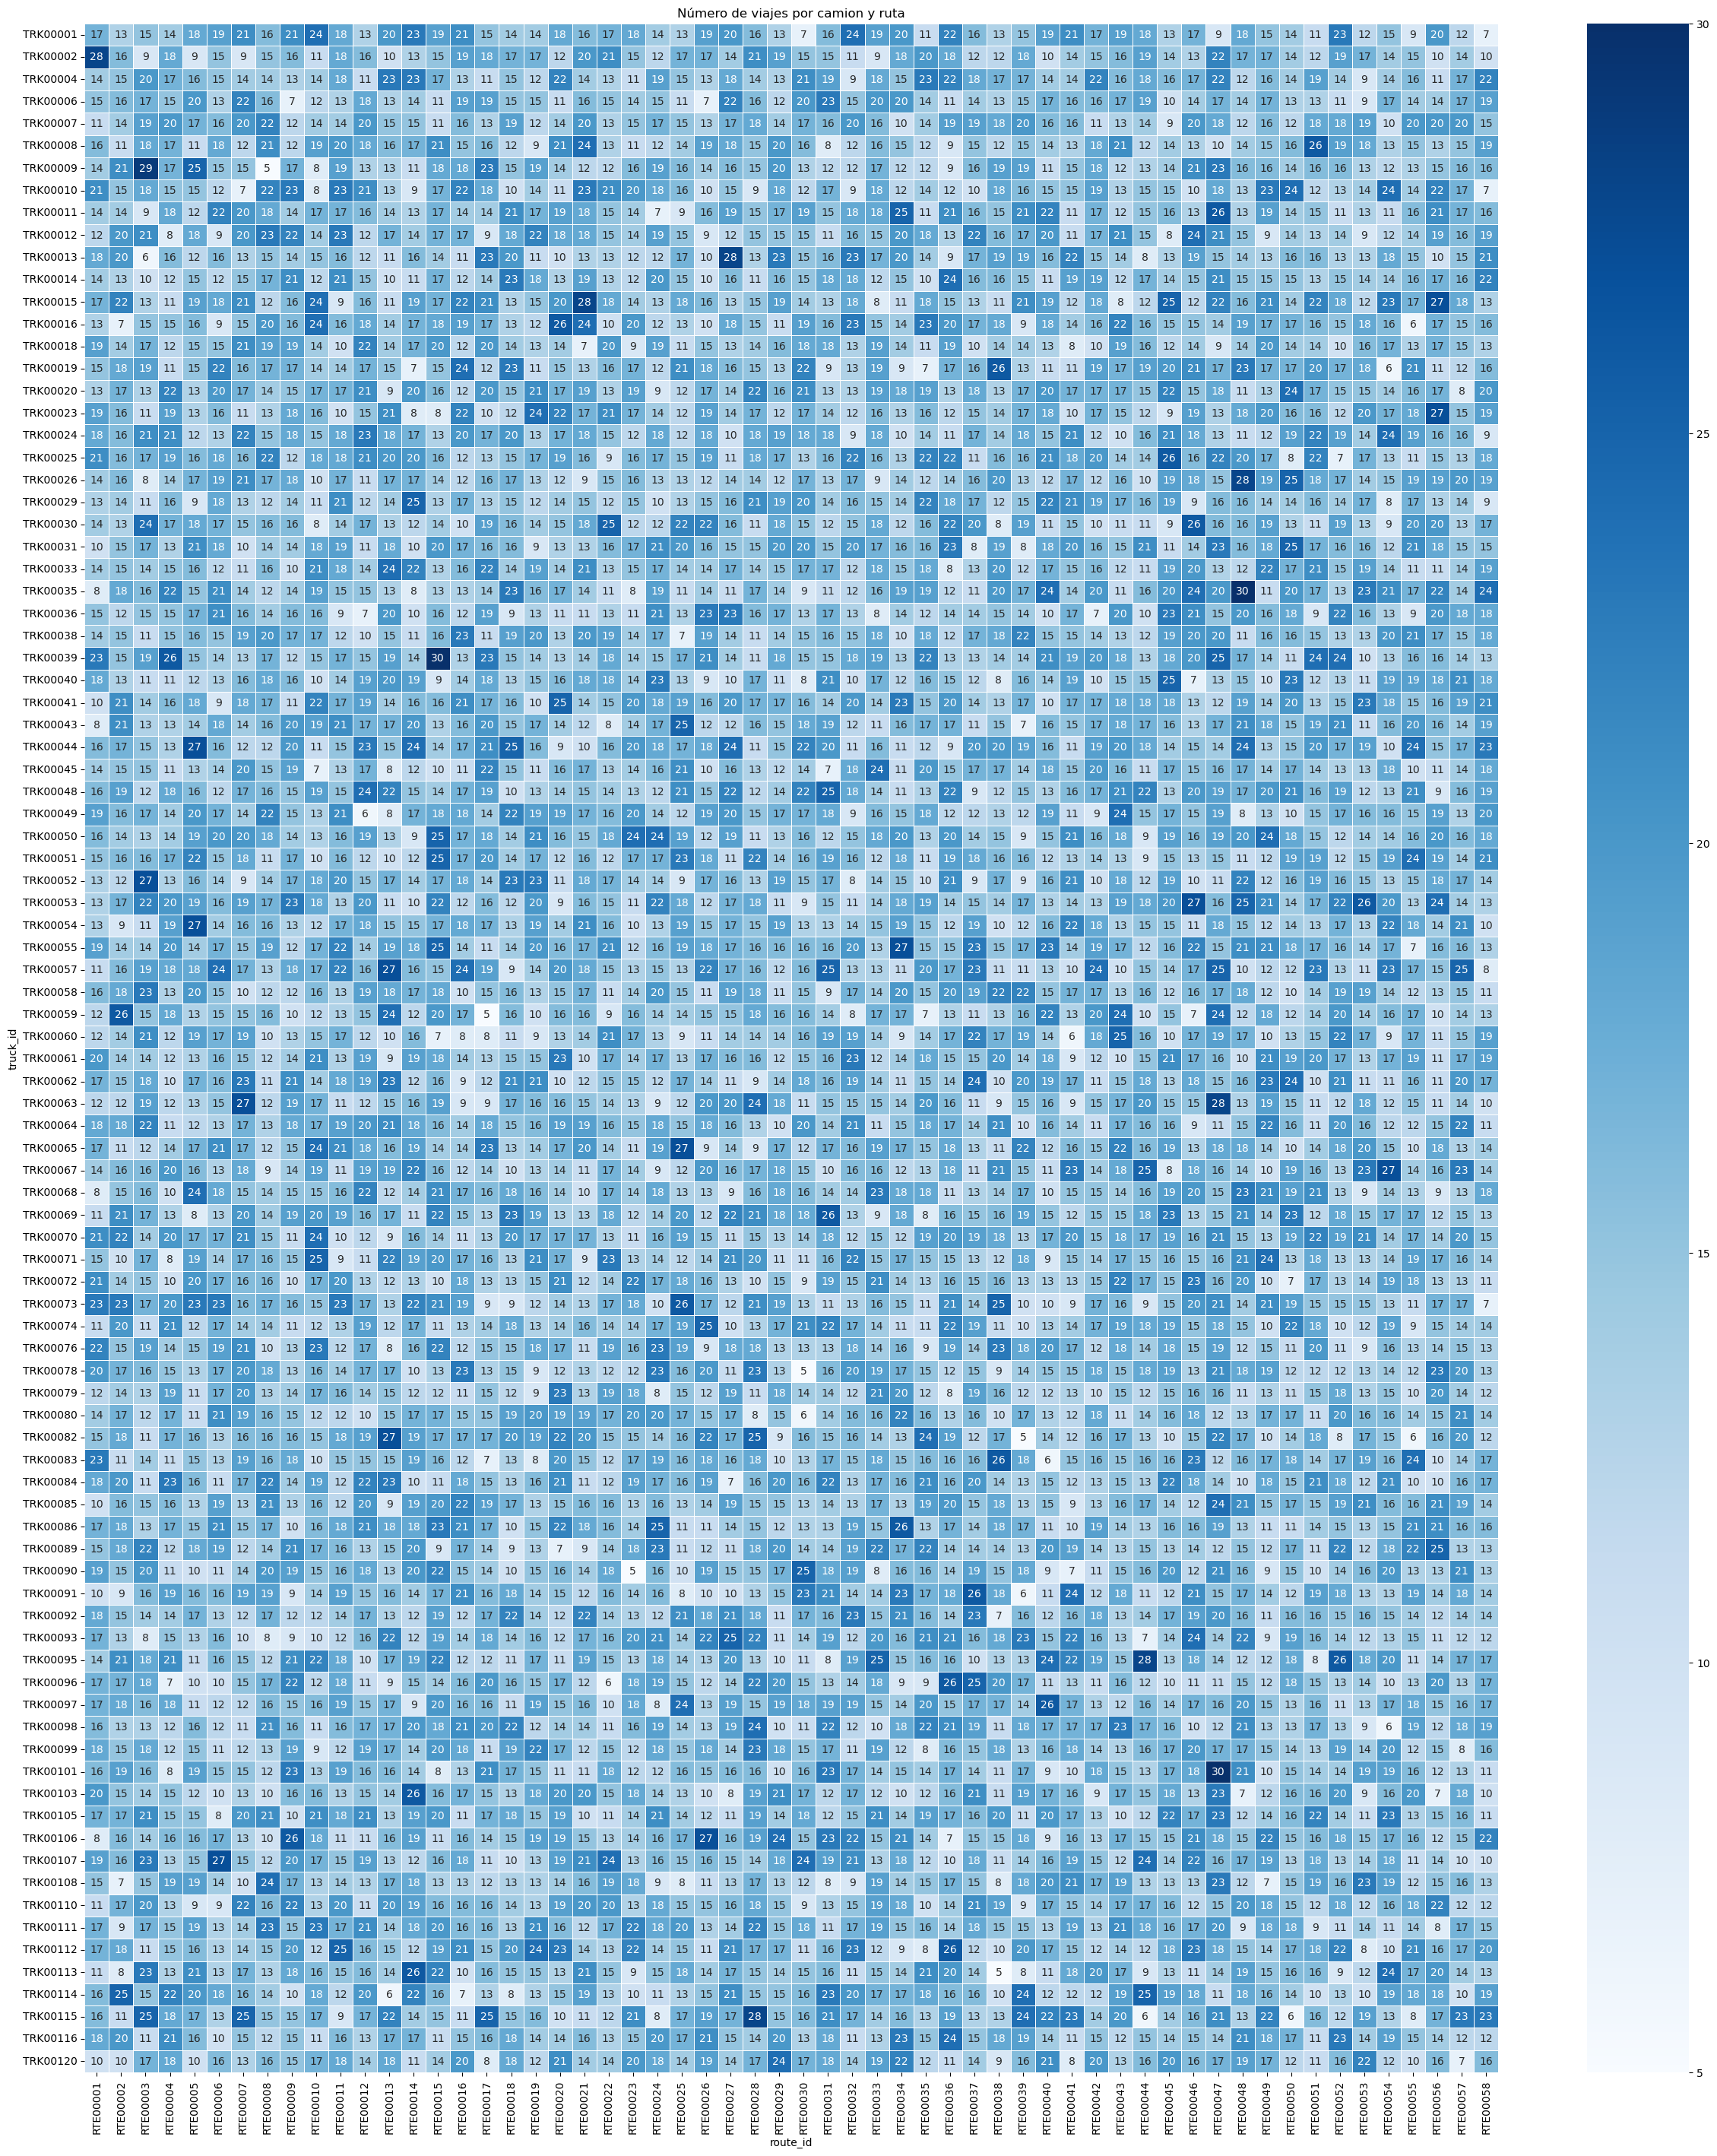

In [20]:
data = df.pivot_table(
    index="truck_id",
    columns="route_id",
    aggfunc="size",
    fill_value=0
)

f, ax = plt.subplots(figsize=(30, 35))
sns.heatmap(
    data,
    annot=True,
    fmt="d",
    linewidths=.5,
    cmap="Blues",
    ax=ax
)
plt.title("Número de viajes por camion y ruta")
plt.show()


In [21]:
columns = ['revenue', 'fuel_surcharge', 'accessorial_charges', 'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'total_revenue']

for col in columns:
    top_10 = (
    df.groupby("truck_id")[col].sum()
    .sort_values(ascending=False)
    .head(10)
    )
    print(f'\n---------------------- Top 10 {col} ----------------------')
    print(top_10)




---------------------- Top 10 revenue ----------------------
truck_id
TRK00044    3045707.57
TRK00107    3022073.78
TRK00041    3017320.99
TRK00055    2997124.44
TRK00053    2990269.38
TRK00015    2979377.79
TRK00025    2942525.23
TRK00024    2938674.70
TRK00057    2933620.12
TRK00035    2926212.82
Name: revenue, dtype: float64

---------------------- Top 10 fuel_surcharge ----------------------
truck_id
TRK00055    348355.64
TRK00041    345886.08
TRK00107    344546.85
TRK00044    343980.05
TRK00015    339777.06
TRK00106    339764.42
TRK00053    337851.82
TRK00025    334460.61
TRK00057    334056.88
TRK00024    333685.64
Name: fuel_surcharge, dtype: float64

---------------------- Top 10 accessorial_charges ----------------------
truck_id
TRK00053    71750
TRK00055    71275
TRK00067    71050
TRK00039    71000
TRK00025    70350
TRK00070    69925
TRK00095    69825
TRK00069    69625
TRK00041    69300
TRK00112    69250
Name: accessorial_charges, dtype: int64

---------------------- Top 10 

<span style="color:orange">relación conductores vs camiones --> la relación que buscábamos de si los conductores en el top_10 llevan loso camiones del top_10 no se dá, salvo en algún caso exceptional como el TRK00057 o el TRK00095

In [22]:
top_10_conductores = (
    df.groupby('driver_id')
    .size()
    .sort_values(ascending=False)
    .head(10).reset_index()
)

top_10_camiones_conductor = df[df['driver_id'].isin(top_10_conductores.driver_id)]
camion_mas_frecuente = (
    top_10_camiones_conductor
    .groupby('driver_id')['truck_id']
    .agg(lambda x: x.mode()[0]) # valor más frecuente
    .reset_index()
)
camion_mas_frecuente


,driver_id,truck_id
0,DRV00016,TRK00065
1,DRV00019,TRK00071
2,DRV00051,TRK00051
3,DRV00059,TRK00074
4,DRV00066,TRK00019
5,DRV00078,TRK00048
6,DRV00087,TRK00057
7,DRV00108,TRK00095
8,DRV00142,TRK00073
9,DRV00149,TRK00052


<span style="color:orange">13. **trailer_id**

ID del trailer que realiza el viaje
<br> Formato: str (TRL00000)
<br> Tenemos un total de 180 trailers.
<br> Aunque no se ven diferencias muy marcadas, podemos sacar rankings de trailers

In [23]:
df['trailer_id'].nunique()

180

In [24]:
columns = ['revenue', 'fuel_surcharge', 'accessorial_charges', 'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'total_revenue']

for col in columns:
    top_10 = (
    df.groupby("trailer_id")[col].sum()
    .sort_values(ascending=False)
    .head(10)
    )
    print(f'\n---------------------- Top 10 {col} ----------------------')
    print(top_10)




---------------------- Top 10 revenue ----------------------
trailer_id
TRL00039    1601736.45
TRL00125    1598348.53
TRL00089    1595815.10
TRL00063    1594851.64
TRL00016    1582020.00
TRL00161    1570910.78
TRL00104    1569139.72
TRL00057    1566607.77
TRL00042    1563542.27
TRL00048    1560170.06
Name: revenue, dtype: float64

---------------------- Top 10 fuel_surcharge ----------------------
trailer_id
TRL00089    182757.12
TRL00099    180885.83
TRL00104    180698.66
TRL00039    180499.82
TRL00125    180466.57
TRL00048    179512.21
TRL00016    179258.05
TRL00082    179017.71
TRL00161    178918.15
TRL00063    178043.57
Name: fuel_surcharge, dtype: float64

---------------------- Top 10 accessorial_charges ----------------------
trailer_id
TRL00016    39050
TRL00119    38175
TRL00104    37850
TRL00053    37575
TRL00157    37525
TRL00031    37300
TRL00063    37050
TRL00099    37000
TRL00102    36925
TRL00134    36800
Name: accessorial_charges, dtype: int64

---------------------- T

<span style="color:orange">14. **dispatch_date**

Fechas en las que se realizaron los viajes
<br> Formato: YYYY-MM-DD
<br> Rango: Desde 2022-01-01 hasta 2024-12-31
<br> Mayor nº apariciones: 2022-05-18 -> Aparece 108 veces
<br> Menor nº apariciones: 2022-03-20 y 2023-10-03 -> Aparece 54 veces

In [25]:
df['dispatch_date'].max()

'2024-12-31'

In [26]:
# Creamos una columna para analizar el tiempo de diferencia entre que se carga el trailer y realiza el viaje
df['load_date'] = pd.to_datetime(df['load_date'])
df['dispatch_date'] = pd.to_datetime(df['dispatch_date'])

df['time_bt_load_trip'] = df['load_date'] - df['dispatch_date']

In [27]:
df['time_bt_load_trip'].value_counts()

time_bt_load_trip
0 days    85410
Name: count, dtype: int64

<span style="color:orange">No hay retrasos con las salidas

<span style="color:orange">15. **actual_distance_miles**

Distancia en millas del viaje.
<br> Formato: int
<br> Mayor valor: 3391 millas
<br> Menos valor: 90 millas
<br> Valor medio: 1430.27 millas
<br> Mediana: 1297.5 millas

In [28]:
df['actual_distance_miles'].info()
df['actual_distance_miles'].min()
df['actual_distance_miles'].max()
(df['actual_distance_miles'].mean()).round(2)
df['actual_distance_miles'].median()

<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: actual_distance_miles
Non-Null Count  Dtype
--------------  -----
85410 non-null  int64
dtypes: int64(1)
memory usage: 667.4 KB


1297.5

<span style="color:orange">16. **actual_duration_hours**

Duración en horas del viaje.
<br> Formato: float
<br> Mayor valor: 67.8 horas
<br> Menos valor: 1.4 horas
<br> Valor medio: 25.01 horas
<br> Mediana: 23 horas

In [29]:
df['actual_duration_hours'].info()
df['actual_duration_hours'].min()
df['actual_duration_hours'].max()
(df['actual_duration_hours'].mean()).round(2)
df['actual_duration_hours'].median()


<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: actual_duration_hours
Non-Null Count  Dtype  
--------------  -----  
85410 non-null  float64
dtypes: float64(1)
memory usage: 667.4 KB


23.0

<span style="color:orange">17. **fuel_gallons_used**

Número de galones utilizados en cada viaje.
<br> Formato: float
<br> Mayor valor: 611.9 galones
<br> Menos valor: 12 galones
<br> Valor medio: 221.83 galones
<br> Mediana: 204.5 galones

In [30]:
df['fuel_gallons_used'].info()
df['fuel_gallons_used'].min()
df['fuel_gallons_used'].max()
(df['fuel_gallons_used'].mean()).round(2)
df['fuel_gallons_used'].median()

<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: fuel_gallons_used
Non-Null Count  Dtype  
--------------  -----  
85410 non-null  float64
dtypes: float64(1)
memory usage: 667.4 KB


204.5

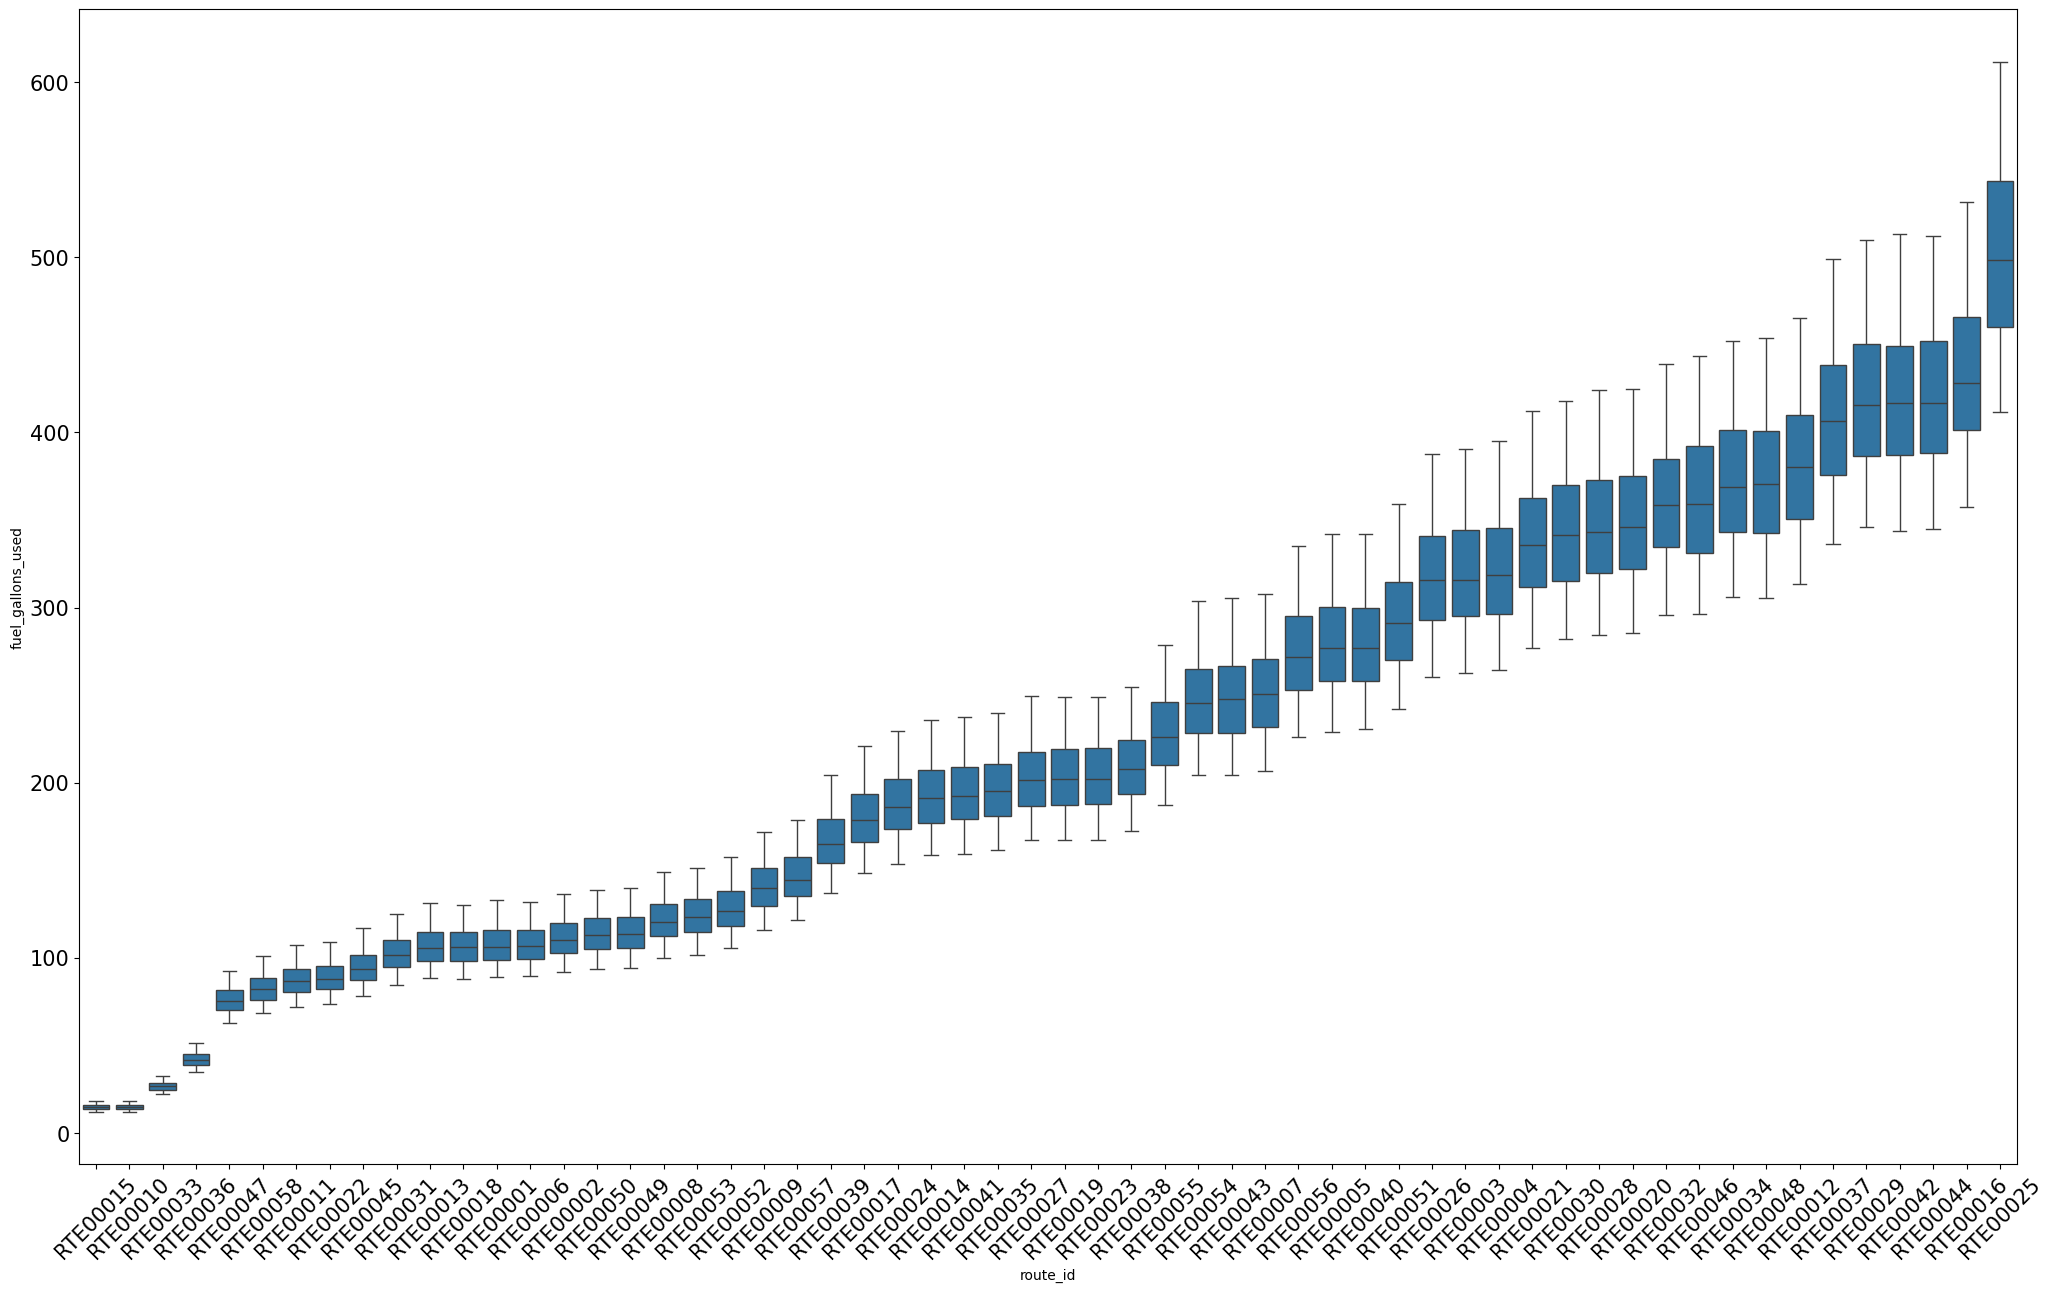

In [31]:
orden = df.groupby('route_id')['fuel_gallons_used'].median().sort_values()
orden_index = orden.index

plt.figure(figsize=(25, 15))

sns.boxplot(
    data=df,
    x='route_id',
    y='fuel_gallons_used',
    order=orden_index
)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.show()


<span style="color:orange">Utilizamos un boxplot para comprobar que cada ruta mantiene los galones utilizados dentro de unos rangos

<span style="color:orange">18. **average_mpg**

Media de millas por galón que se han hecho en cada viaje, podemos buscar relación con el peso de la carga por ejemplo.
<br> Formato: float
<br> Mayor valor: 7.5 millas/galón
<br> Menos valor: 5.5 millas/galón
<br> Valor medio: 6.5 millas/galón
<br> Mediana: 6.5 millas/galón

No hay relación entre el peso y el gasto


In [32]:
df['average_mpg'].info()
df['average_mpg'].min()
df['average_mpg'].max()
(df['average_mpg'].mean()).round(2)
df['average_mpg'].median()

<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: average_mpg
Non-Null Count  Dtype  
--------------  -----  
85410 non-null  float64
dtypes: float64(1)
memory usage: 667.4 KB


6.5

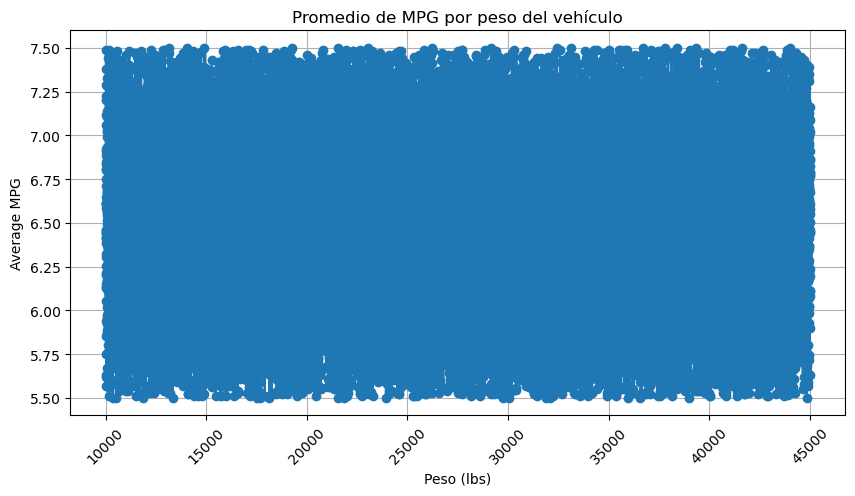

In [33]:
import matplotlib.pyplot as plt

# Calcular la media de millas por galón por peso
df_grouped = df.groupby('weight_lbs')['average_mpg'].mean().sort_index()

plt.figure(figsize=(10,5))

# Gráfico de línea
plt.plot(df_grouped.index, df_grouped.values, marker='o')
plt.title('Promedio de MPG por peso del vehículo')
plt.xlabel('Peso (lbs)')
plt.ylabel('Average MPG')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


<span style="color:orange">19. **idle_time_hours**

Tiempo de inactividad durante el viaje.
<br> Formato: float
<br> Mayor valor: 12 horas
<br> Menos valor: 2 horas
<br> Valor medio: 7.01 horas
<br> Mediana: 7 horas

No hay relación con las otras variables


In [34]:
df['idle_time_hours'].info()
df['idle_time_hours'].min()
df['idle_time_hours'].max()
(df['idle_time_hours'].mean()).round(2)
df['idle_time_hours'].median()

<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: idle_time_hours
Non-Null Count  Dtype  
--------------  -----  
85410 non-null  float64
dtypes: float64(1)
memory usage: 667.4 KB


7.0

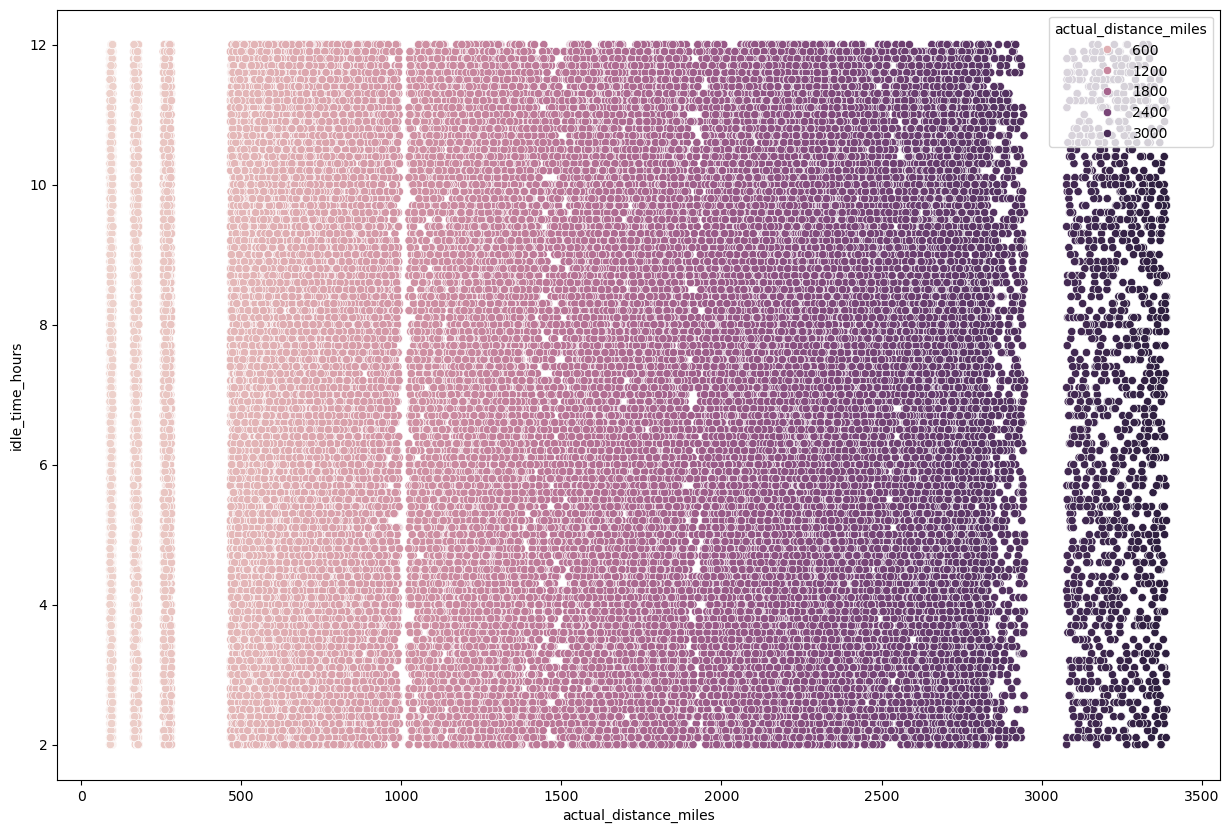

In [35]:
plt.figure(figsize=(15,10))
sns.scatterplot(x=df['actual_distance_miles'], y=df['idle_time_hours'], hue=df['actual_distance_miles'])

plt.xlabel('actual_distance_miles')
plt.ylabel('idle_time_hours')
plt.show()

<span style="color:orange">20. **total_revenue**

KPI más importante, calcula el beneficio total, revenue - fuel_surcharge - accessorial_charges
<br> Formato: float
<br> Mayor valor: 7381
<br> Menos valor: - 89.6
<br> Valor medio: 2651.1
<br> Mediana: 2417.49

Fuerte relación con revenue, fuel_surcharge, actual_distance_miles, actual_duration_hours y fuel_gallong_used
La tendencia es a viajes más largos, mayores beneficios.


In [36]:
df['total_revenue'].info()
df['total_revenue'].min()
df['total_revenue'].max()
(df['total_revenue'].mean()).round(2)
df['total_revenue'].median()

<class 'pandas.core.series.Series'>
RangeIndex: 85410 entries, 0 to 85409
Series name: total_revenue
Non-Null Count  Dtype  
--------------  -----  
85410 non-null  float64
dtypes: float64(1)
memory usage: 667.4 KB


2417.49

<span style="color:orange"> Se encuentran 345 viajes, por los que por algún motivo, la empresa pierde dinero con ellos

In [37]:
viajes_beneficios_negativos = df[df['total_revenue']<0]
viajes_beneficios_negativos.value_counts().sum()

np.int64(345)

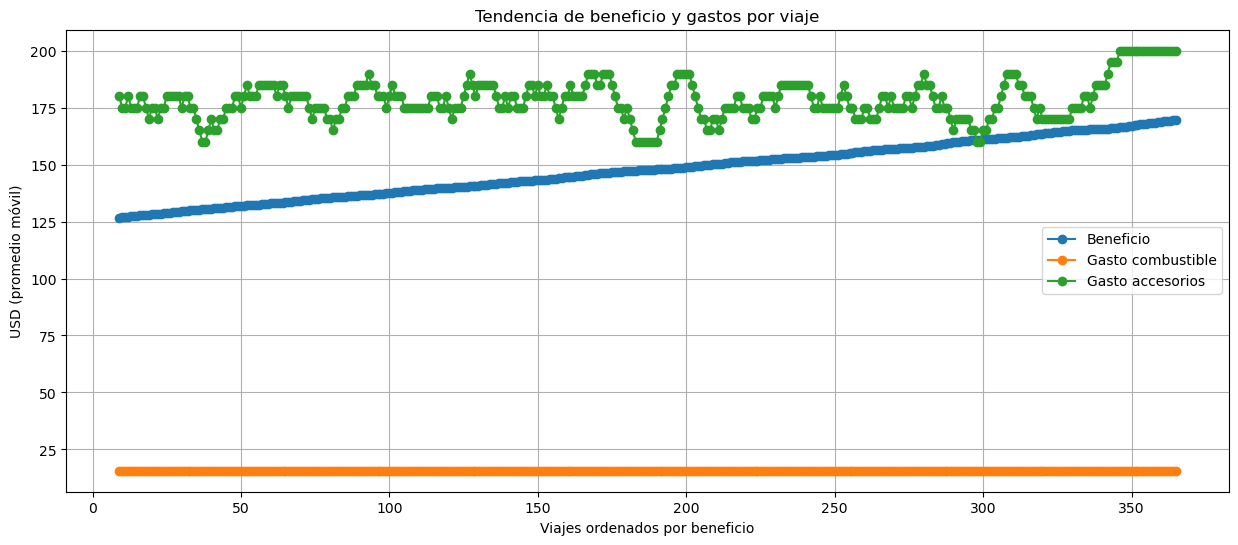

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

df_sorted = viajes_beneficios_negativos.sort_values('revenue').reset_index(drop=True)
window = 10

plt.figure(figsize=(15,6))

# Líneas suavizadas
plt.plot(df_sorted['revenue'].rolling(window).mean(), label='Beneficio', marker='o')
plt.plot(df_sorted['fuel_surcharge'].rolling(window).mean(), label='Gasto combustible', marker='o')
plt.plot(df_sorted['accessorial_charges'].rolling(window).mean(), label='Gasto accesorios', marker='o')

plt.xlabel('Viajes ordenados por beneficio')
plt.ylabel('USD (promedio móvil)')
plt.title('Tendencia de beneficio y gastos por viaje')
plt.legend()
plt.grid(True)
plt.show()

<span style="color:orange">Podemos ver que el principal problema para estos viajes es el recargo por accesorios, también vemos que son viajes cortos (entre 90 y 99 millas), probablemente de clientes que tambén realizan encargos más grandes y compensan por ese lado

In [39]:
viajes_beneficios_negativos['actual_distance_miles'].max()

99

In [40]:
viajes_beneficios_bajos = df[(df['total_revenue'] > 0) & (df['total_revenue'] < 1000)]
viajes_beneficios_bajos.value_counts().sum()

np.int64(13744)

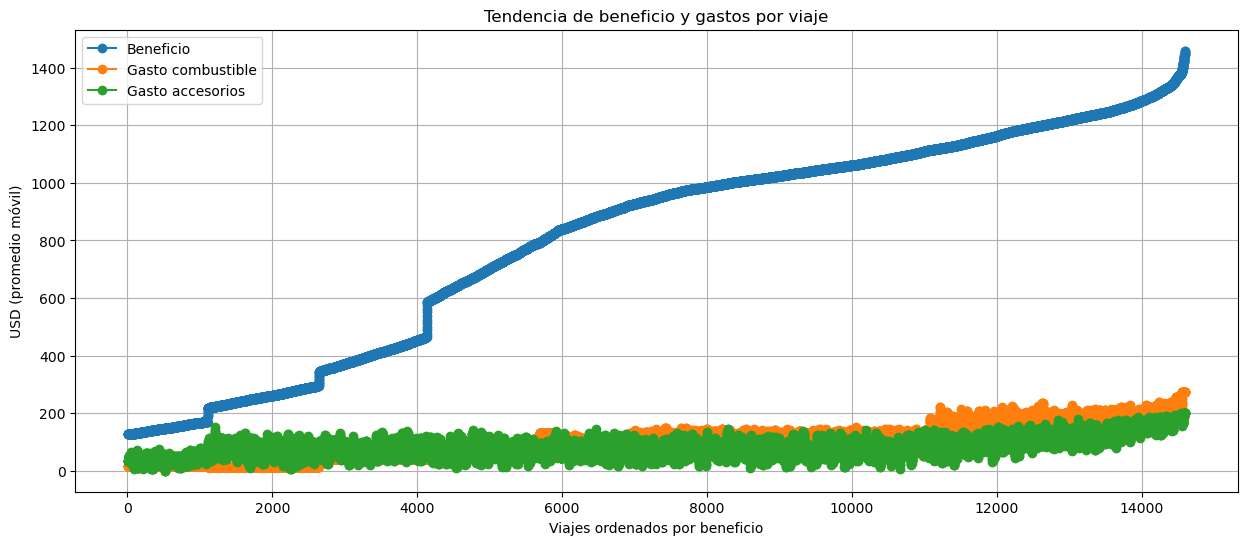

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

df_sorted = viajes_beneficios_bajos.sort_values('revenue').reset_index(drop=True)
window = 10

plt.figure(figsize=(15,6))

# Líneas suavizadas
plt.plot(df_sorted['revenue'].rolling(window).mean(), label='Beneficio', marker='o')
plt.plot(df_sorted['fuel_surcharge'].rolling(window).mean(), label='Gasto combustible', marker='o')
plt.plot(df_sorted['accessorial_charges'].rolling(window).mean(), label='Gasto accesorios', marker='o')

plt.xlabel('Viajes ordenados por beneficio')
plt.ylabel('USD (promedio móvil)')
plt.title('Tendencia de beneficio y gastos por viaje')
plt.legend()
plt.grid(True)
plt.show()

<span style="color:orange">A medida que sube el beneficio del viaje, los recargos por combustible y accesorios afectan menos al beneficio total

In [42]:
viajes_beneficios_altos = df[(df['total_revenue'] > 7000)]
viajes_beneficios_altos.value_counts().sum()

np.int64(381)